In [1]:
%pip install -e ~/deltakit-textbook
%pip install "mlx[cpu]"

Looking in links: /usr/share/pip-wheels
Obtaining file:///home/f73aeabd-6de4-471d-92a9-1ba552ae6153/deltakit-textbook
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for deltakit-textbook (pyproject.toml) ... done
  Created wheel for deltakit-textbook: filename=deltakit_textbook-0.0.0-0.editable-py3-none-any.whl size=4827 sha256=50e815367f71612a2d37c0c632f870b4255026ff23529fb751f72e92e1d1ef21
  Stored in directory: /tmp/pip-ephem-wheel-cache-_p8umonu/wheels/5d/bd/f8/449a5f5525755c7915b059424bb229b7b46fd90882998f3811
Successfully built deltakit-textbook
  Attempting uninstall: deltakit-textbook
    Found existing installation: deltakit-textbook 0.0.0
    Uninstalling deltakit-textbook-0.0.0:
      Successfully uninstalled deltakit-textbook-0.0.0
Note: you may need to restart the kernel to use updated packages.

# Running faster circuit simulations

So far, you have learned about bit-flip and phase-flip repetition codes. In the process, you have also seen how these error-correcting codes perform by simulating their behavior -- to do this, you ran quantum circuits containing different amounts of errors, and observed how the codes perform under these settings.

For bit-flip repetition codes, we ran our quantum circuits with up to 1 million repetitions and were able to see logical error probabilities of order 1 in 1 million. You saw that running 1 million shots/repetitions took about a second. On the other hand, for phase-flip repetition codes, where we needed to create a new quantum circuit for each instance of the code with varying levels of noise, it took about 30 seconds to collect statistics by running 50,000 circuits at the smallest `distance = 3`. However, in order to test the performance of these error-correcting codes down to the 1 in 1 billion level, we will somehow need to run billions of circuits, which seems prohibitively expensive.

The reason for the significant slowdown in the phase-flip setting is related to the need for tracking where we inserted errors -- we needed to do this to determine when our decoded syndromes were successfully predictive of these locations. Because each circuit contains a different instance of noise on some subset of the data qubits, our general execution structure was

```
for each distance
    for each physical qubit error level
        for 50000 shots
            create 1 random instance of the circuit, record where errors were inserted
            run that circuit
            decode the syndrome measurements
            determine whether a logical error happened (decoded error locations ?= inserted error locations), if so add to count         
```

In contrast, in the bit-flip case, our execution structure was
```
for each distance
    for each physical qubit error level
        create one instance of the circuit containing probabilistic error gates
        run that circuit 1000000 times
        decode the syndrome measurements
        for each shot:
            determine whether a logical error happened (decoded error locations ?= inserted error locations), if so add to count       
```

Note that we are taking full advantage of the Clifford simulation capability of `cirq` when we run the same circuit 1 million times in the bit-flip case, but lose that benefit when we run 1 circuit each time in the phase-flip case and incur the overhead of running that circuit each time.

In this notebook, we will dramatically improve the execution speed of the phase-flip repetition code, reducing it from 30 seconds for 50,000 shots to 5 seconds for 10 billion shots. In the process, you will see some of the techniques that the standard tools of QEC employ to run these simulations quickly.

## <font color='blue'>0. Starting point</font>

We will demonstrate a number of techniques for speeding up the simulations of the performance of our phase-flip repetition codes. These techniques are generally applicable, and are routinely used in quantum error correction research. 

### Simulation settings

This notebook uses small shot counts and code distances to keep test
runs manageable on my computer. These settings check that the code runs;
they are not intended for precise statistical results.

Comments beside the parameters indicate the intended larger-run values.
Increase them when sufficient computing resources are available.

### Simulation settings

This notebook uses small shot counts and code distances to keep test
runs manageable on my computer. These settings check that the code runs;
they are not intended for precise statistical results.

Comments beside the parameters indicate the intended larger-run values.
Increase them when sufficient computing resources are available.

In [2]:
from math import floor, comb
import numpy as np
import matplotlib.pyplot as plotter, matplotlib.cm as cm
import cirq
from myMWPM import MWPMDecoder1D
from tqdm import tqdm
from collections import Counter
from itertools import combinations
from joblib import Parallel, delayed
import qec 

In [3]:
simulator = cirq.Simulator()
logical_state = '+'
error_gate = cirq.Z
physical_errors = np.logspace(-3, 0, 10)
n_workers=8 

In [4]:
# Use n_shots = 10_000_000 for more precise estimates and smaller
# statistical fluctuations, at the cost of longer computation time.
n_shots = 10  # Quick test; results may have large statistical fluctuations.


distances = [3]

all_logical_errors = []
for distance in distances:        
    print(f"Running distance {distance}, phase-flip rep code, initialized as |{logical_state}>_L, error gate {error_gate}")
    thisdistance_logicalerrors = []
    for error_probability in tqdm(physical_errors):
        logical_error_probability = qec.logical_error.get_logical_error_probability_for_rep_code(distance, error_probability, 
                                                                               logical_state, error_gate, n_shots, simulator)
        thisdistance_logicalerrors.append(logical_error_probability)
    all_logical_errors.append(thisdistance_logicalerrors)

Running distance 3, phase-flip rep code, initialized as |+>_L, error gate Z


100%|██████████| 10/10 [00:01<00:00,  9.09it/s]


As you can see, each physical error takes about 30 seconds to run with 50,000 shots at distance 3.

## <font color='blue'>1. Reducing the number of quantum circuits that we need to run redundantly (800x speedup)</font>

Recall the structure of our execution for the phase-flip repetition code.

```
for each distance
    for each physical qubit error probability
        for n_shots=50000 shots
            create 1 random instance of the circuit, record where errors were inserted
            run that circuit
            decode the syndrome measurements
            determine whether a logical error happened (decoded error locations ?= inserted error locations), if so add to count         
```

Note that we are running `number of shots` $\times$ `number of distances` $\times$ `number of physical errors` circuits.

Each random noisy instance of the circuit contains some combination of Pauli-$Z$ gates on the data qubits. Since we know the number of data qubits ($d$), there are at most $d$ different ways to place a single Pauli-$Z$ gate, $d-$choose$-2$ ways to place two Pauli-$Z$ gates, and so on. More generally, there are a total of $2^d$ different combinations of circuits. We can enumerate these by writing an array with $d$ entries that are either 0 or 1, where 0 (1) signifies the absence (presence) of a $Z$ gate, for a total of $2^d$ possible such arrays.

Using this observation, we can replace our execution to the following:

```
### first, create the syndrome table by running circuits containing all possible error locations only once

for each d = distance
    create all 2^d circuits with noise inserted at all possible combinations of qubits
    run those 2^d circuits and measure the syndromes
    decode the 2^d syndrome measurements
    determine whether a logical error happened (decoded error locations ?= inserted error locations); save to syndrome table with decision for later lookup

### next, sample from the syndrome table

for each distance
    for each physical qubit error probability
        generate a matrix with (rows = n_shots, columns = distance); each row is an error pattern generated using the physical qubit error probability
        look up each row in the syndrome table and determine if a logical error occurs
        sum the number of times a logical error occurred, and divide by n_shots to get a probability
```
Note that we are now running only `2^d` circuits. Since matrix manipulation can be done very quickly, the rest of the steps add very little execution time, and the speedup becomes significant. We implement this procedure below.

In [5]:
distances = [3]

In [6]:
# Use n_shots = 10_000_000 for more precise estimates and smaller
# statistical fluctuations, at the cost of longer computation time.
n_shots = 50  # Quick test; results may have large statistical fluctuations. 

all_logical_errors = []
for distance in distances:        
    print(f"Running distance {distance}, phase-flip rep codes, initialized as |{logical_state}>_L, error gate {error_gate}")
    decoded_syndrome_table = qec.syndrome_extraction.compute_decoded_syndrome_table( n_qubits=distance,
            logical_state=logical_state,
            error_gate=error_gate,
            simulator=simulator,)
    thisdistance_logicalerrors = []
    for error_probability in tqdm(physical_errors):
        logical_error_probability = qec.syndrome_extraction.simulate_with_syndrome_table( decoded_syndrome_table=decoded_syndrome_table,
                n_qubits=distance,
                error_probability=error_probability,
                n_shots= 50,) 
        thisdistance_logicalerrors.append(logical_error_probability)
    all_logical_errors.append(thisdistance_logicalerrors)

Running distance 3, phase-flip rep codes, initialized as |+>_L, error gate Z
Getting syndromes for all possible error locations in distance 3, |+>_L
Done getting syndromes for all possible error locations in distance 3, |+>_L


100%|██████████| 10/10 [00:00<00:00, 7741.42it/s]


As you can see, we have sped up our simulations significantly. 

### <font color='red'>Chunking and batching to reduce memory usage</font>

Note that our current implementation of `simulate_with_syndrome_table` creates an array of size `(n_shots, n_qubits)`. For 10 million shots, this may not matter much. But for simulations where the logical error probability is in the $10^{-9}$ range, we will require about a billion shots. At that point, memory usage is significant. Try running the above example with 1 billion shots to see what happens! (Hint: it will take a prohibitively long time to get a datapoint).

We can solve this problem by generating error patterns for 100,000,000 shots at a time, and processing batches of 10,000 error patterns at a time by looking them up in the syndrome table.

```
### chunked and batched sampling from the syndrome table
for each distance
    for each physical qubit error probability
    
        n_chunks = total number of shots / memory limit
        for each chunk:
        
            n_batches = chunk size / batch size
            for each batch:
            
                generate a matrix with (rows = batch size, columns = distance); each row is an error pattern generated using the physical qubit error probability
                look up each row in the syndrome table and determine if a logical error occurs
                add to total logical error count if this specific row leads to logical errors
    
    sum the number of times a logical error occurred, and divide by n_shots to get a probability
```

Note that chunking and processing in batches does not result in a speedup, but reduces the memory usage.

In [7]:
all_logical_errors = []
for distance in distances:        
    print(f"Running distance {distance}, phase-flip rep codes, |{logical_state}>_L, error gate {error_gate}")
    decoded_syndrome_table = qec.syndrome_extraction.compute_decoded_syndrome_table(n_qubits = distance, logical_state = logical_state, error_gate = error_gate, simulator = simulator)
    thisdistance_logicalerrors = []
    for error_probability in tqdm(physical_errors):
        logical_error_probability = qec.syndrome_extraction.simulate_with_syndrome_table(decoded_syndrome_table = decoded_syndrome_table, n_qubits = distance, error_probability = error_probability, n_shots = n_shots)
        thisdistance_logicalerrors.append(logical_error_probability)
    all_logical_errors.append(thisdistance_logicalerrors)

Running distance 3, phase-flip rep codes, |+>_L, error gate Z
Getting syndromes for all possible error locations in distance 3, |+>_L
Done getting syndromes for all possible error locations in distance 3, |+>_L


100%|██████████| 10/10 [00:00<00:00, 16858.14it/s]


## <font color='blue'>2. Parallelizing execution of batches of circuits across CPUs (6000x speedup)</font>

Now that we have rearranged the execution of `simulate_with_syndrome_table` into chunks, with each chunk itself broken into smaller batches, we can parallelize the execution of those batches across several CPUs (and later on GPUs). This should give a speedup of the execution by a factor of the number of CPUs used, assuming that we are able to orchestrate and aggregate the results from each of those CPUs efficiently.

Thankfully, Python makes this easy with the use of the `joblib` library. To do this, we will first define a parallelized version of `simulate_with_syndrome_table` called `simulate_with_syndrome_table_parallel` which runs each batch across `n_workers` CPU threads.

Then, sampling from the syndrome table now looks like the following:

```
### chunked and batched sampling from the syndrome table
for each distance
    for each physical qubit error probability
    
        n_chunks = total number of shots / memory limit
        for each chunk:
        
            n_batches = chunk size / batch size
            run single batches across multiple CPU threads:
                generate a matrix with (rows = batch size, columns = distance); each row is an error pattern generated using the physical qubit error probability
                look up each row in the syndrome table and determine if a logical error occurs
                add to total logical error count if this specific row leads to logical errors
    
    sum the number of times a logical error occurred, and divide by n_shots to get a probability
```

In [8]:
distances = [3]

In [9]:
all_logical_errors = []
for distance in distances:        
    print(f"Running distance {distance}, phase-flip rep codes, |{logical_state}>_L, error gate {error_gate}")
    decoded_syndrome_table = qec.syndrome_extraction.compute_decoded_syndrome_table( n_qubits=distance, logical_state=logical_state, error_gate=error_gate, simulator=simulator,)
    
    thisdistance_logicalerrors = []
    for error_probability in tqdm(physical_errors):
        logical_error_probability = qec.syndrome_extraction.simulate_with_syndrome_table_parallel( decoded_syndrome_table=decoded_syndrome_table, n_qubits=distance, error_probability=error_probability,  n_shots= n_shots, n_workers=n_workers,)

        thisdistance_logicalerrors.append(logical_error_probability)
    all_logical_errors.append(thisdistance_logicalerrors)

Running distance 3, phase-flip rep codes, |+>_L, error gate Z
Getting syndromes for all possible error locations in distance 3, |+>_L
Done getting syndromes for all possible error locations in distance 3, |+>_L


100%|██████████| 10/10 [01:54<00:00, 11.47s/it]


As you can see, it now takes about 1 second for 10 million shots of a specific physical error probability at distance 3. This is another 6-7x speedup on top of the gains from using a syndrome table. You may notice that we have used `n_workers = 8` above. The author's laptop has 8 performance cores on an Apple MacBook Pro M2 Max, which motivated this choice. The resulting 6-7x speedup is quite close to the number of CPUs, and the remaining bottleneck is orchestration across these CPUs.

## <font color='blue'>3. Adding GPUs to the mix (1,000,000x speedup)</font>

GPUs are particularly well-suited for matrix operations. We can take full advantage of this by running the syndrome table sampling on GPUs. In this section, we focus our efforts on adapting the syndrome sampling procedure to run on the GPUs in an Apple MacBook Pro with Apple's M2 Max processor, using Apple's MLX library. However, the techniques used here are generally adaptable to other GPUs.

Recall that we created the syndrome table as a dictionary indexed by `tuple(specific_error_locations)`. This `tuple` contains `1` where the qubits had errors, and `0` where they didn't.

```python
decoded_syndrome_table = {}
for specific_error_locations, syndromes, decoded_error_locations in zip(all_possible_error_locations, all_syndromes, all_decoded_error_locations):
    is_logical_error = set(specific_error_locations) != set(decoded_error_locations)
    decoded_syndrome_table[tuple(specific_error_locations)] = [syndromes, decoded_error_locations, is_logical_error]
```

To sample the syndrome table on a GPU, we will first convert this syndrome table into a GPU-friendly format. Then, we will run batches of size `100MB` at a time on the GPU, until all shots are completed. This number is specific to the memory available on your computer -- at distance 9, it requires approximately `9 bits x 100MB ≈ 0.9 GB` of memory.

In [10]:
try:
    import mlx.core as mx  # Apple's MLX library for Apple Silicon
except ImportError:
    raise RuntimeError("MLX not available")

In [11]:
distances = [3, 5, 7, 9]

In [12]:
all_logical_errors = []
for distance in distances:        
    print(f"Running distance {distance}, phase-flip rep codes, |{logical_state}>_L, error gate {error_gate}")
    decoded_syndrome_table = qec.syndrome_extraction.compute_decoded_syndrome_table(n_qubits = distance, logical_state = logical_state, error_gate = error_gate, simulator = simulator)
    thisdistance_logicalerrors = []
    for error_probability in tqdm(physical_errors):
        logical_error_probability = qec.utils.simulate_with_syndrome_table_parallel_GPU_mlx(syndrome_table = decoded_syndrome_table, n_qubits = distance, error_probability = error_probability, n_shots = n_shots)
        thisdistance_logicalerrors.append(logical_error_probability)
    all_logical_errors.append(thisdistance_logicalerrors)

Running distance 3, phase-flip rep codes, |+>_L, error gate Z
Getting syndromes for all possible error locations in distance 3, |+>_L
Done getting syndromes for all possible error locations in distance 3, |+>_L


100%|██████████| 10/10 [00:00<00:00, 3218.22it/s]

Running distance 5, phase-flip rep codes, |+>_L, error gate Z
Getting syndromes for all possible error locations in distance 5, |+>_L


Done getting syndromes for all possible error locations in distance 5, |+>_L


100%|██████████| 10/10 [00:00<00:00, 1792.74it/s]

...

Done getting syndromes for all possible error locations in distance 7, |+>_L


100%|██████████| 10/10 [00:00<00:00, 107.39it/s]

Running distance 9, phase-flip rep codes, |+>_L, error gate Z
Getting syndromes for all possible error locations in distance 9, |+>_L


Done getting syndromes for all possible error locations in distance 9, |+>_L


100%|██████████| 10/10 [00:00<00:00, 24.77it/s]


As you can see, it now takes about 5 seconds for 10 billion shots of a specific physical error probability at distance 3. This is another 200x speedup on top of the gains from using a syndrome table and parallelizing across CPU threads. 

The key benefit of being able to run 10B ($10\times10^9$) shots is that we can simulate the performance of our error-correcting codes down to logical errors of order $\sim10^{-9}$, where the benefits of quantum error correction are expected to enable useful quantum algorithms.

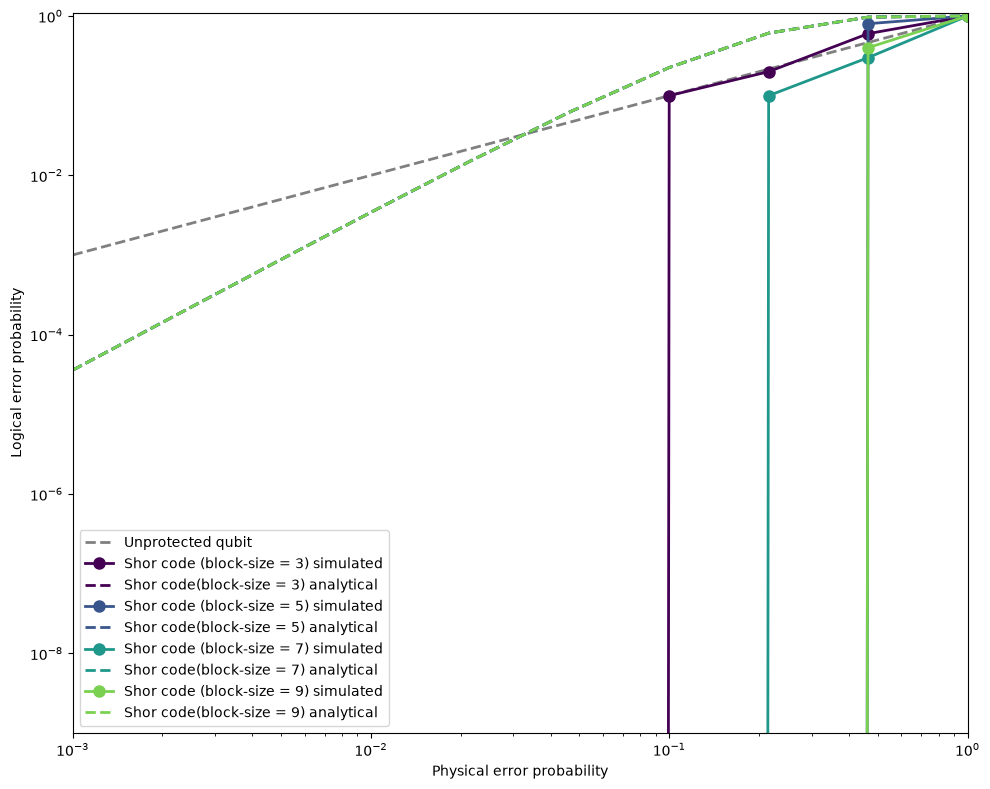

In [13]:
all_analytical_errors = qec.logical_error.get_logical_error_probability_analytical(distances, physical_errors)
qec.visualization.plot_logical_error_probabilities(distances, physical_errors, all_logical_errors, all_analytical_errors, ylim=[1e-9, 1.1])

## <font color='blue'>4. Hints for further speedup</font>

So far, we have sampled all $10\times10^9$ shots from the syndrome table. By reducing the number of circuit executions to just the number of circuits needed to prepare the syndrome table, and sampling from that table repeatedly without running circuits, we have achieved the speedups that we have seen so far.

To motivate additional speedups, it's instructive to look at the generated error patterns that we are looking up in the syndrome table. Below, we demonstrate the error patterns for distance 7, with physical error probability $p_{err}=0.2$, and 1 million shots.

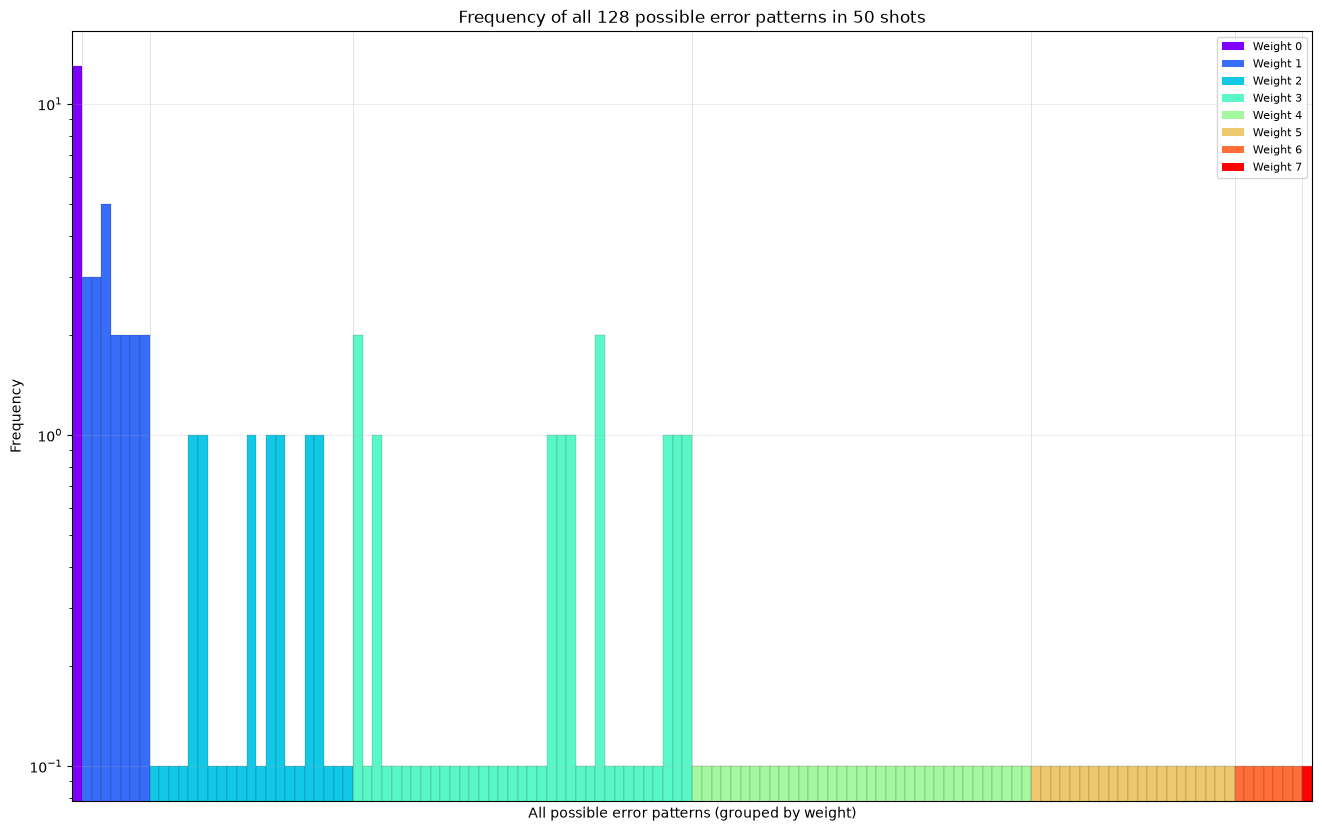

In [14]:
 # n_shots = 10000000  
    
qec.visualization.show_error_pattern_distribution(7, 0.2, 50)

As you can see, there is only one way to have weight-0 errors (no errors on all qubits), and that occurs with a frequency of about 200,000 times out of a total of 1 million samples (20% $ \approx p_{err}^0 \cdot (1 - p_{err})^7 = 1 \cdot 0.8^7$), 7 different ways to have weight-1 errors (one error on each qubit at distance 7), each of which occurs about 50,000 times (5% $ \approx p_{err}^1 \cdot (1 - p_{err})^6 = 0.2 \cdot 0.8^6$), and so on. 

So far, we have been sampling all error patterns (in the above example, we would have sampled all 1 million error patterns). But as you can see above, there is a significant amount of redundancy in doing so, and grouping should provide significant speedup if we can predetermine the weights of these groupings.

Can you take advantage of this observation to further reduce the simulation time? If so, as you can see above, there is an additional ~10000x to be gained. :)